# Week 3: Feature Selection and Dimensionality Reduction (Forward/Backward Selection, PCR, PLSR)

## 1. Notebook Setup
- Import libraries  
- Define helper functions for model evaluation and feature selection

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import statsmodels.api as sm

#evaluate regression model
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return {"MSE": mse, "R2": r2}

# Forward selection
def forward_selection(X, y, significance_level=0.05):
    initial_features = []
    best_features = []
    while True:
        remaining_features = list(set(X.columns) - set(initial_features))
        new_pval = pd.Series(index=remaining_features)
        for new_column in remaining_features:
            model = sm.OLS(y, sm.add_constant(X[initial_features + [new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        min_p_value = new_pval.min()
        if min_p_value < significance_level:
            best_feature = new_pval.idxmin()
            initial_features.append(best_feature)
            best_features.append(best_feature)
        else:
            break
    return best_features

# Backward elimination
def backward_elimination(X, y, significance_level=0.05):
    features = X.columns.tolist()
    while len(features) > 0:
        X_with_const = sm.add_constant(X[features]) #add constant
        model = sm.OLS(y, X_with_const).fit()
        
        #drop constant from pvalues
        pvalues = model.pvalues.drop("const", errors="ignore")
        
        max_p_value = pvalues.max()
        if max_p_value >= significance_level:
            excluded_feature = pvalues.idxmax()
            features.remove(excluded_feature)
        else:
            break
    return features

## 2. Dataset 1: customer_churn
### 2.1 Data Overview & Preparation

In [2]:
#load data
train_cc = pd.read_csv('customer_churn_dataset-training-master.csv')
test_cc = pd.read_csv('customer_churn_dataset-testing-master.csv')
#combine train and test set
customer_churn = pd.concat([train_cc, test_cc], ignore_index=True)
#drop null rows
customer_churn.dropna(inplace=True)
#drop CustomerID column (shouldn't impact churn)
customer_churn.drop("CustomerID", axis=1, inplace=True)

X = pd.get_dummies(customer_churn.drop("Churn", axis=1, errors="ignore"), drop_first=True)
y = customer_churn["Churn"] if "Churn" in customer_churn.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
X_train.dtypes

Age                           float64
Tenure                        float64
Usage Frequency               float64
Support Calls                 float64
Payment Delay                 float64
Total Spend                   float64
Last Interaction              float64
Gender_Male                      bool
Subscription Type_Premium        bool
Subscription Type_Standard       bool
Contract Length_Monthly          bool
Contract Length_Quarterly        bool
dtype: object

In [4]:
#convert bool cols to numeric for OLS
X_train = X_train.astype(float)
X_test = X_test.astype(float)

### 2.2 Forward Selection

In [5]:
forward_selection(X_train, y_train)

['Gender_Male',
 'Contract Length_Quarterly',
 'Contract Length_Monthly',
 'Support Calls',
 'Payment Delay',
 'Last Interaction',
 'Age',
 'Total Spend',
 'Usage Frequency',
 'Tenure',
 'Subscription Type_Premium',
 'Subscription Type_Standard']

In [6]:
if y is not None:
    selected_features_forward = forward_selection(X_train, y_train)
    print("Selected features (Forward):", selected_features_forward)

Selected features (Forward): ['Gender_Male', 'Contract Length_Quarterly', 'Contract Length_Monthly', 'Support Calls', 'Payment Delay', 'Last Interaction', 'Age', 'Total Spend', 'Usage Frequency', 'Tenure', 'Subscription Type_Premium', 'Subscription Type_Standard']


### 2.3 Backward Elimination

In [7]:
if y is not None:
    selected_features_backward = backward_elimination(X_train, y_train)
    print("Selected features (Backward):", selected_features_backward)

Selected features (Backward): ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender_Male', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly']


### 2.4 Principal Component Regression (PCR)

In [8]:
if y is not None:
    pca = PCA(n_components=min(10, X_train.shape[1]))
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    lr = LinearRegression()
    results_pcr = evaluate_model(lr, X_train_pca, X_test_pca, y_train, y_test)
    print("PCR Results:", results_pcr)

PCR Results: {'MSE': 0.13951252957668914, 'R2': 0.43515780177391794}


### 2.5 Partial Least Squares Regression (PLSR)

In [9]:
if y is not None:
    plsr = PLSRegression(n_components=min(10, X_train.shape[1]))
    plsr.fit(X_train, y_train)
    y_pred = plsr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("PLSR Results:", {"MSE": mse, "R2": r2})

PLSR Results: {'MSE': 0.1347346519826265, 'R2': 0.4545019201213816}


#### Relevant Plots:
scree plot:

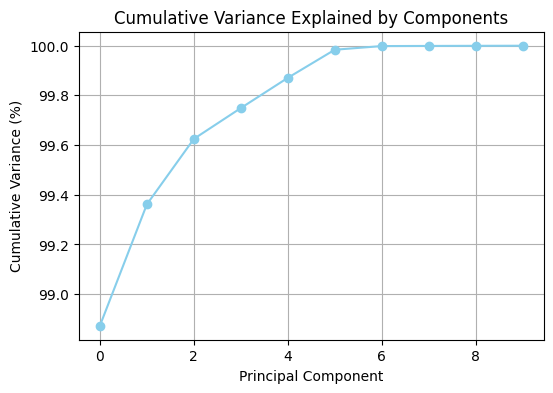

In [10]:
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o', color='skyblue')
plt.title("Cumulative Variance Explained by Components")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance (%)")
plt.grid(True)
plt.show()

first component loadings:

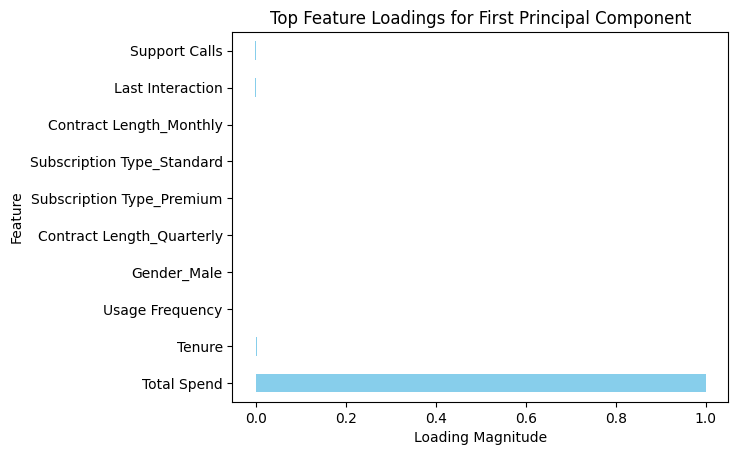

In [11]:
loadings = pd.Series(pca.components_[0], index=X.columns).sort_values(ascending=False)
loadings.head(10).plot(kind='barh', color='skyblue')
plt.title("Top Feature Loadings for First Principal Component")
plt.xlabel("Loading Magnitude")
plt.ylabel("Feature")
plt.show()

## 3. Dataset 2: digital_marketing_campaign
### 3.1 Data Overview & Preparation

In [12]:
digital_marketing = pd.read_csv("digital_marketing_campaign_dataset.csv")
digital_marketing.dropna(inplace=True)
X = pd.get_dummies(digital_marketing.drop("Conversion", axis=1, errors="ignore"), drop_first=True)
y = digital_marketing["Conversion"] if "Conversion" in digital_marketing.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train.dtypes

CustomerID                        int64
Age                               int64
Income                            int64
AdSpend                         float64
ClickThroughRate                float64
ConversionRate                  float64
WebsiteVisits                     int64
PagesPerVisit                   float64
TimeOnSite                      float64
SocialShares                      int64
EmailOpens                        int64
EmailClicks                       int64
PreviousPurchases                 int64
LoyaltyPoints                     int64
Gender_Male                        bool
CampaignChannel_PPC                bool
CampaignChannel_Referral           bool
CampaignChannel_SEO                bool
CampaignChannel_Social Media       bool
CampaignType_Consideration         bool
CampaignType_Conversion            bool
CampaignType_Retention             bool
dtype: object

In [14]:
#convert bool cols to numeric for OLS
X_train = X_train.astype(float)
X_test = X_test.astype(float)

### 3.2 Forward Selection

In [15]:
if y is not None:
    selected_features_forward = forward_selection(X_train, y_train)
    print("Selected features (Forward):", selected_features_forward)

Selected features (Forward): ['CustomerID', 'EmailOpens', 'EmailClicks', 'TimeOnSite', 'ClickThroughRate', 'AdSpend', 'PreviousPurchases', 'PagesPerVisit', 'LoyaltyPoints', 'CampaignType_Conversion', 'ConversionRate', 'WebsiteVisits', 'CampaignChannel_Social Media']


### 3.3 Backward Elimination

In [16]:
if y is not None:
    selected_features_backward = backward_elimination(X_train, y_train)
    print("Selected features (Backward):", selected_features_backward)

Selected features (Backward): ['CustomerID', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'CampaignChannel_Social Media', 'CampaignType_Conversion']


### 3.4 Principal Component Regression (PCR)

In [17]:

if y is not None:
    pca = PCA(n_components=min(10, X_train.shape[1]))
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    lr = LinearRegression()
    results_pcr = evaluate_model(lr, X_train_pca, X_test_pca, y_train, y_test)
    print("PCR Results:", results_pcr)


PCR Results: {'MSE': 0.09730716581309203, 'R2': 0.08673305684945376}


### 3.5 Partial Least Squares Regression (PLSR)

In [18]:

if y is not None:
    plsr = PLSRegression(n_components=min(10, X_train.shape[1]))
    plsr.fit(X_train, y_train)
    y_pred = plsr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("PLSR Results:", {"MSE": mse, "R2": r2})


PLSR Results: {'MSE': 0.0916124808601833, 'R2': 0.1401799687566203}


#### Relevant Plots:
scree plot:

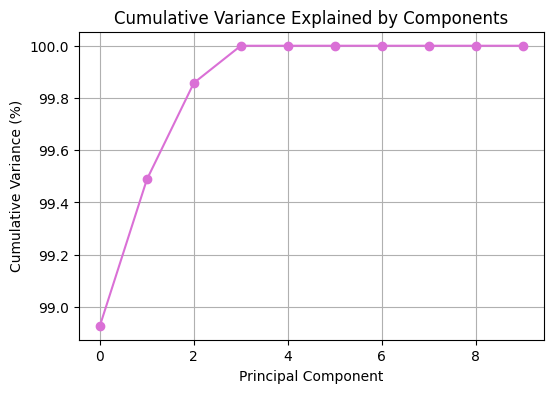

In [19]:
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o', color='orchid')
plt.title("Cumulative Variance Explained by Components")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance (%)")
plt.grid(True)
plt.show()

first component loadings:

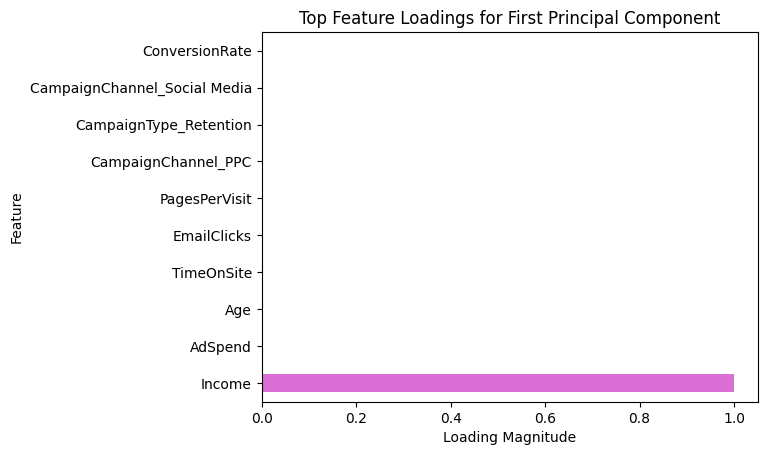

In [20]:
loadings = pd.Series(pca.components_[0], index=X.columns).sort_values(ascending=False)
loadings.head(10).plot(kind='barh', color='orchid')
plt.title("Top Feature Loadings for First Principal Component")
plt.xlabel("Loading Magnitude")
plt.ylabel("Feature")
plt.show()

## 4. Dataset 3: marketing_campaign (Optional for Week 3)
### 4.1 Data Overview & Preparation

In [21]:
marketing_campaign = pd.read_csv("marketing_campaign.csv", sep=';')
marketing_campaign.dropna(inplace=True)
X = pd.get_dummies(marketing_campaign.drop("Response", axis=1, errors="ignore"), drop_first=True)
y = marketing_campaign["Response"] if "Response" in marketing_campaign.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
X_train.dtypes

ID                          int64
Year_Birth                  int64
Income                    float64
Kidhome                     int64
Teenhome                    int64
                           ...   
Dt_Customer_2014-06-25       bool
Dt_Customer_2014-06-26       bool
Dt_Customer_2014-06-27       bool
Dt_Customer_2014-06-28       bool
Dt_Customer_2014-06-29       bool
Length: 697, dtype: object

In [23]:
#convert bool cols to numeric for OLS
X_train = X_train.astype(float)
X_test = X_test.astype(float)

### 4.2 Forward Selection

In [24]:

if y is not None:
    selected_features_forward = forward_selection(X_train, y_train)
    print("Selected features (Forward):", selected_features_forward)


Selected features (Forward): ['Z_Revenue', 'AcceptedCmp5', 'AcceptedCmp3', 'AcceptedCmp1', 'Recency', 'Z_CostContact', 'Dt_Customer_2012-11-09', 'AcceptedCmp4', 'MntMeatProducts', 'NumWebVisitsMonth', 'Marital_Status_Single', 'Education_PhD', 'Dt_Customer_2012-09-03', 'Marital_Status_Divorced', 'Dt_Customer_2012-10-15', 'Dt_Customer_2013-05-03', 'Dt_Customer_2012-09-04', 'Dt_Customer_2013-02-22', 'Dt_Customer_2013-01-01', 'Dt_Customer_2012-09-17', 'NumStorePurchases', 'MntGoldProds', 'Dt_Customer_2013-04-03', 'Dt_Customer_2012-11-19', 'Dt_Customer_2013-03-01', 'Dt_Customer_2013-01-24', 'Dt_Customer_2013-04-02', 'Dt_Customer_2013-03-04', 'Dt_Customer_2013-03-10', 'AcceptedCmp2', 'Dt_Customer_2014-02-14', 'Dt_Customer_2012-09-18', 'Dt_Customer_2012-09-07', 'Dt_Customer_2014-04-10', 'Dt_Customer_2013-04-30', 'Dt_Customer_2012-08-13', 'Dt_Customer_2012-10-02', 'Dt_Customer_2012-08-17', 'Dt_Customer_2012-11-02', 'Dt_Customer_2012-08-18', 'Dt_Customer_2012-08-16', 'Dt_Customer_2013-02-01', '

### 4.3 Backward Elimination

In [25]:
if y is not None:
    selected_features_backward = backward_elimination(X_train, y_train)
    print("Selected features (Backward):", selected_features_backward)

Selected features (Backward): ['Teenhome', 'Recency', 'MntMeatProducts', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Z_CostContact', 'Z_Revenue', 'Education_PhD', 'Marital_Status_Divorced', 'Marital_Status_Single', 'Marital_Status_Widow', 'Dt_Customer_2013-01-06', 'Dt_Customer_2013-04-29', 'Dt_Customer_2013-10-02', 'Dt_Customer_2013-10-04', 'Dt_Customer_2014-02-14', 'Dt_Customer_2014-03-01', 'Dt_Customer_2014-05-12']


### 4.4 Principal Component Regression (PCR)

In [26]:

if y is not None:
    pca = PCA(n_components=min(10, X_train.shape[1]))
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    lr = LinearRegression()
    results_pcr = evaluate_model(lr, X_train_pca, X_test_pca, y_train, y_test)
    print("PCR Results:", results_pcr)


PCR Results: {'MSE': 0.10175302577681411, 'R2': 0.15304912643396262}


### 4.5 Partial Least Squares Regression (PLSR)

In [27]:

if y is not None:
    plsr = PLSRegression(n_components=min(10, X_train.shape[1]))
    plsr.fit(X_train, y_train)
    y_pred = plsr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("PLSR Results:", {"MSE": mse, "R2": r2})


PLSR Results: {'MSE': 0.13555247818151, 'R2': -0.12828379238262788}


#### Relevant Plots:
scree plot:

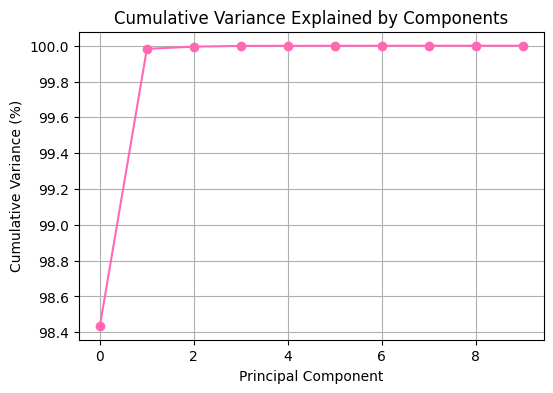

In [28]:
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o', color='hotpink')
plt.title("Cumulative Variance Explained by Components")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance (%)")
plt.grid(True)
plt.show()

first component loadings:

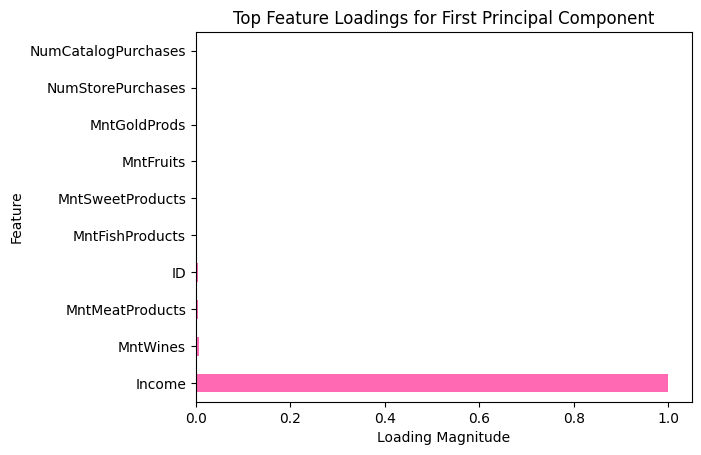

In [29]:
loadings = pd.Series(pca.components_[0], index=X.columns).sort_values(ascending=False)
loadings.head(10).plot(kind='barh', color='hotpink')
plt.title("Top Feature Loadings for First Principal Component")
plt.xlabel("Loading Magnitude")
plt.ylabel("Feature")
plt.show()